# Airline Delay Risk Classification: Audit-Strengthened Final AI/ML Project

This notebook implements a leakage-aware, reproducible binary classification study for airline delay risk. It includes data validation, EDA, threshold design, feature engineering, stratified train/validation/test splitting, Logistic Regression, a neural network model, hyperparameter tuning, cross-validation, feature importance, visual diagnostics, metrics export, and an explicit audit summary.

In [1]:

import os, json, warnings, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
OUT_FIG = PROJECT_ROOT / 'outputs' / 'figures'
OUT_MET = PROJECT_ROOT / 'outputs' / 'metrics'
OUT_TAB = PROJECT_ROOT / 'outputs' / 'tables'
REPORT_DIR = PROJECT_ROOT / 'reports'
for p in [OUT_FIG, OUT_MET, OUT_TAB, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)


Project root: c:\Users\Admin\Desktop\final_project


## 1. Data Loading and Schema Validation

The unit of analysis is an aggregated `(year, month, carrier, airport)` record. The target is constructed after validation, and direct target components are excluded from predictive features to reduce leakage.

In [2]:

expected_columns = [
    'year','month','carrier','carrier_name','airport','airport_name','arr_flights','arr_del15',
    'carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct','arr_cancelled','arr_diverted',
    'arr_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay'
]
candidate_files = sorted(DATA_DIR.glob('*.csv'))
assert candidate_files, f'No CSV files found in {DATA_DIR}'
preferred = DATA_DIR / 'Airline_Delay_Cause.csv'
csv_path = preferred if preferred.exists() else candidate_files[0]
df_raw = pd.read_csv(csv_path)
missing_expected = [c for c in expected_columns if c not in df_raw.columns]
assert not missing_expected, f'Missing expected columns: {missing_expected}'
print('Using dataset:', csv_path)
print('Raw shape:', df_raw.shape)
print(df_raw.dtypes)
df_raw.head()


Using dataset: c:\Users\Admin\Desktop\final_project\data\Airline_Delay_Cause.csv
Raw shape: (171666, 21)
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


## 2. Data Cleaning and Missingness

String fields are normalized, numeric fields are coerced, and rows with missing or non-positive arrival-flight counts are removed because `arr_flights` is the denominator of the target ratio.

Removed 240 rows due to missing/non-positive arr_flights


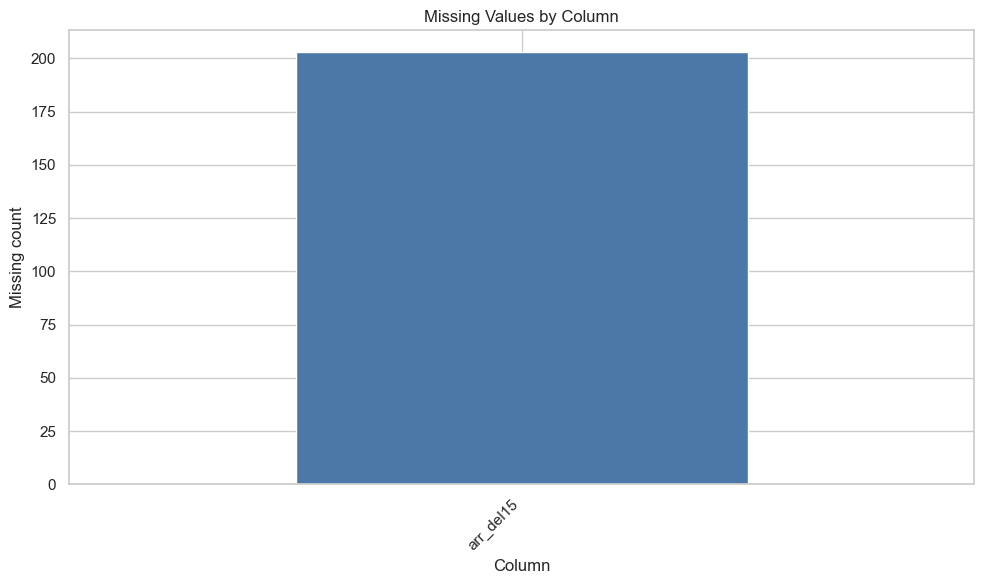

,missing_count,missing_pct
arr_del15,203,0.118
month,0,0.000
carrier,0,0.000
carrier_name,0,0.000
year,0,0.000
airport,0,0.000
airport_name,0,0.000
arr_flights,0,0.000
carrier_ct,0,0.000
weather_ct,0,0.000


In [3]:

df = df_raw.copy()
str_cols = ['carrier','carrier_name','airport','airport_name']
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
for c in [x for x in df.columns if x not in str_cols]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

before = len(df)
df = df[df['arr_flights'].notna() & (df['arr_flights'] > 0)].copy()
removed_rows = before - len(df)
print(f'Removed {removed_rows} rows due to missing/non-positive arr_flights')

missing_summary = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(3)
missing_table = pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})
missing_table.to_csv(OUT_TAB / 'missing_values_summary.csv')

plt.figure(figsize=(10,6))
plot_missing = missing_table[missing_table['missing_count'] > 0]
if len(plot_missing):
    plot_missing['missing_count'].plot(kind='bar', color='#4c78a8')
else:
    plt.bar(['No missing values'], [0], color='#4c78a8')
plt.title('Missing Values by Column')
plt.ylabel('Missing count')
plt.xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_FIG / 'missing_values_bar.png', dpi=180)
plt.show()
missing_table.head(20)


## 3. Target Engineering and Threshold Validation

The target is `high_delay_risk`, derived from `delay_ratio = arr_del15 / arr_flights`. The notebook evaluates multiple candidate thresholds and selects the best-balanced predefined candidate to avoid an unnecessarily unstable minority class.

   threshold  positive_rate  negative_rate  minority_share
0     0.3000       0.126835       0.873165        0.126835
1     0.2500       0.232603       0.767397        0.232603
2     0.2415       0.250042       0.749958        0.250042
Selected threshold: 0.2415
Positive rate: 0.25


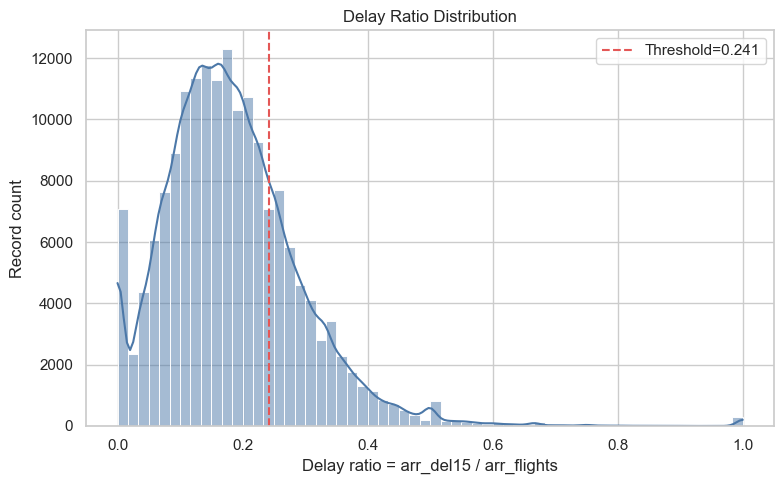

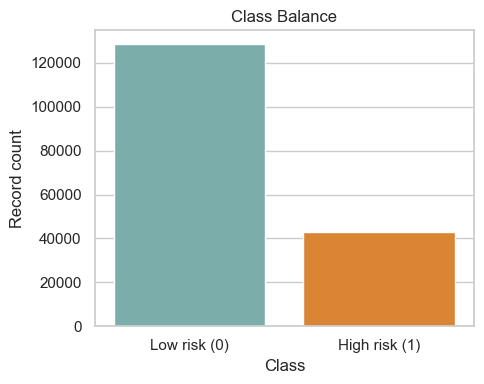

In [4]:

df['delay_ratio'] = df['arr_del15'] / df['arr_flights']
df['delay_ratio'] = df['delay_ratio'].replace([np.inf, -np.inf], np.nan)
df = df[df['delay_ratio'].notna()].copy()
p75 = float(df['delay_ratio'].quantile(0.75))
candidates = [0.30, 0.25, round(p75, 4)]
rows=[]
for t in candidates:
    y_tmp = (df['delay_ratio'] >= t).astype(int)
    pos_rate = float(y_tmp.mean())
    rows.append({'threshold':t,'positive_rate':pos_rate,'negative_rate':1-pos_rate,'minority_share':min(pos_rate,1-pos_rate)})
threshold_analysis = pd.DataFrame(rows).sort_values('threshold', ascending=False)
threshold_analysis.to_csv(OUT_TAB / 'threshold_class_balance.csv', index=False)
minority_030 = float(threshold_analysis.loc[threshold_analysis['threshold'].round(4)==0.30, 'minority_share'].iloc[0])
if minority_030 >= 0.15:
    selected_threshold = 0.30
    threshold_reason = 'Selected 0.30 for interpretability with acceptable class balance.'
else:
    best_row = threshold_analysis.sort_values('minority_share', ascending=False).iloc[0]
    selected_threshold = float(best_row['threshold'])
    threshold_reason = '0.30 produced stronger imbalance; selected the best-balanced predefined candidate.'
df['high_delay_risk'] = (df['delay_ratio'] >= selected_threshold).astype(int)
print(threshold_analysis)
print('Selected threshold:', selected_threshold)
print('Positive rate:', round(float(df['high_delay_risk'].mean()), 4))

plt.figure(figsize=(8,5))
sns.histplot(df['delay_ratio'], bins=60, kde=True, color='#4c78a8')
plt.axvline(selected_threshold, color='#e45756', linestyle='--', label=f'Threshold={selected_threshold:.3f}')
plt.title('Delay Ratio Distribution')
plt.xlabel('Delay ratio = arr_del15 / arr_flights')
plt.ylabel('Record count')
plt.legend()
plt.tight_layout(); plt.savefig(OUT_FIG / 'delay_ratio_distribution.png', dpi=180); plt.show()

class_counts = df['high_delay_risk'].value_counts().sort_index()
plt.figure(figsize=(5,4))
sns.barplot(x=['Low risk (0)', 'High risk (1)'], y=class_counts.values, palette=['#72b7b2','#f58518'])
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Record count')
plt.tight_layout(); plt.savefig(OUT_FIG / 'class_balance.png', dpi=180); plt.show()


## 4. Exploratory Data Analysis

EDA checks seasonality, carrier heterogeneity, airport heterogeneity, disruption signals, cause distributions, and numeric correlation patterns.

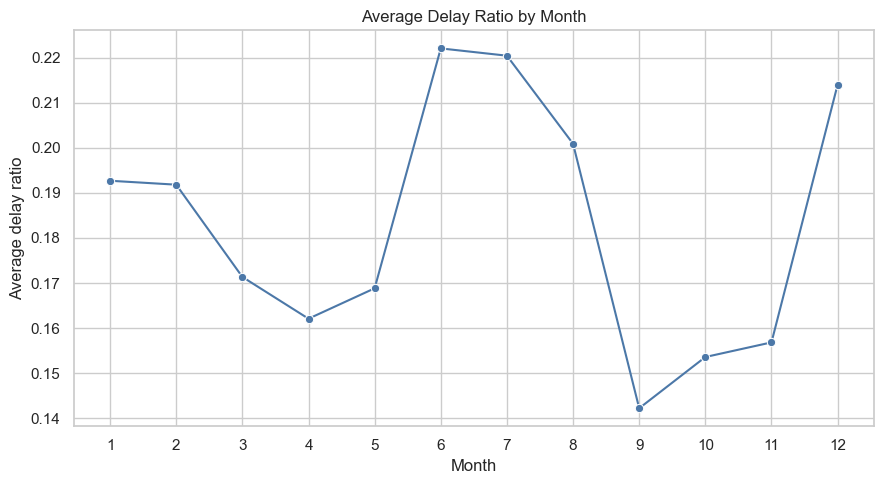

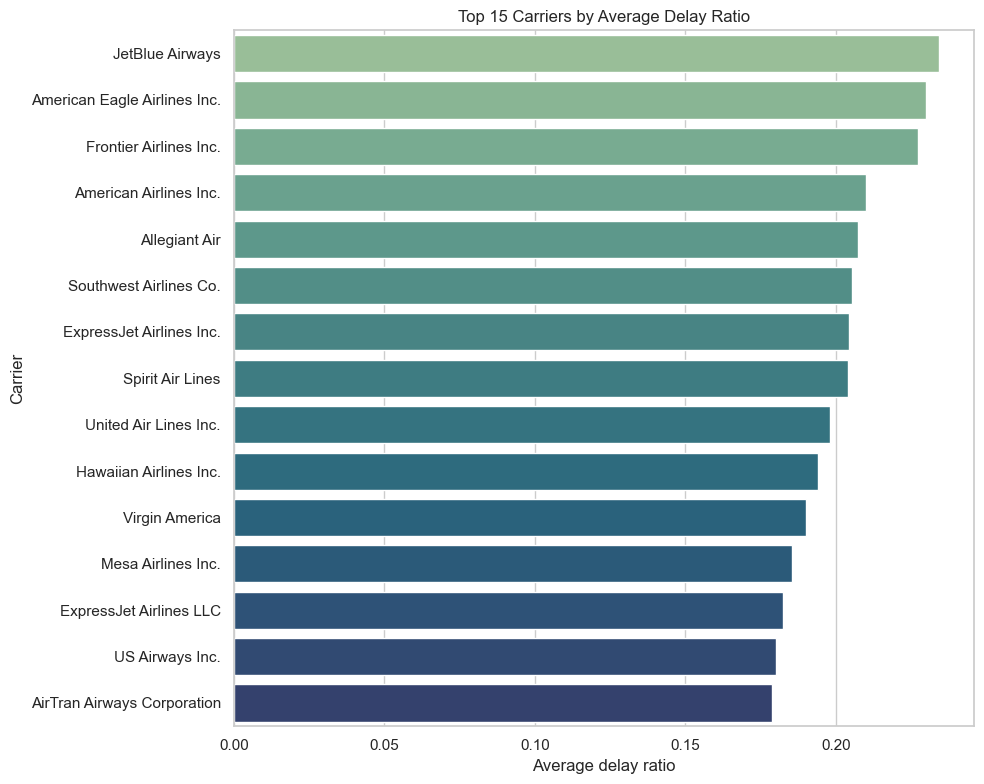

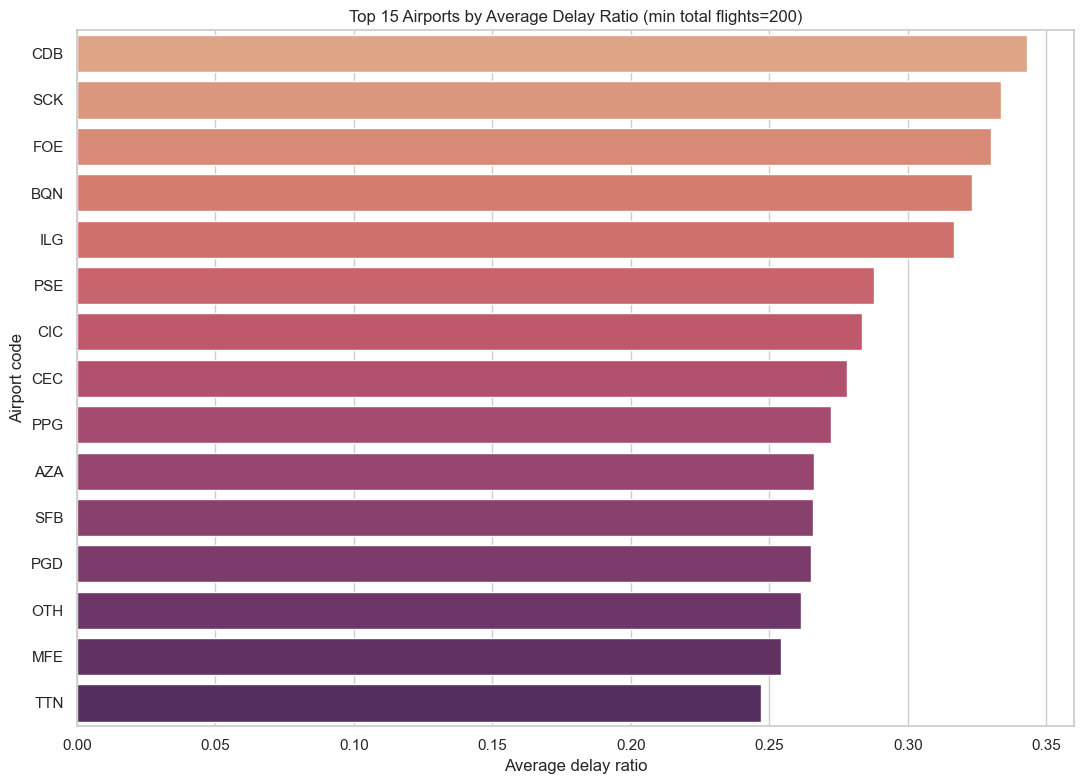

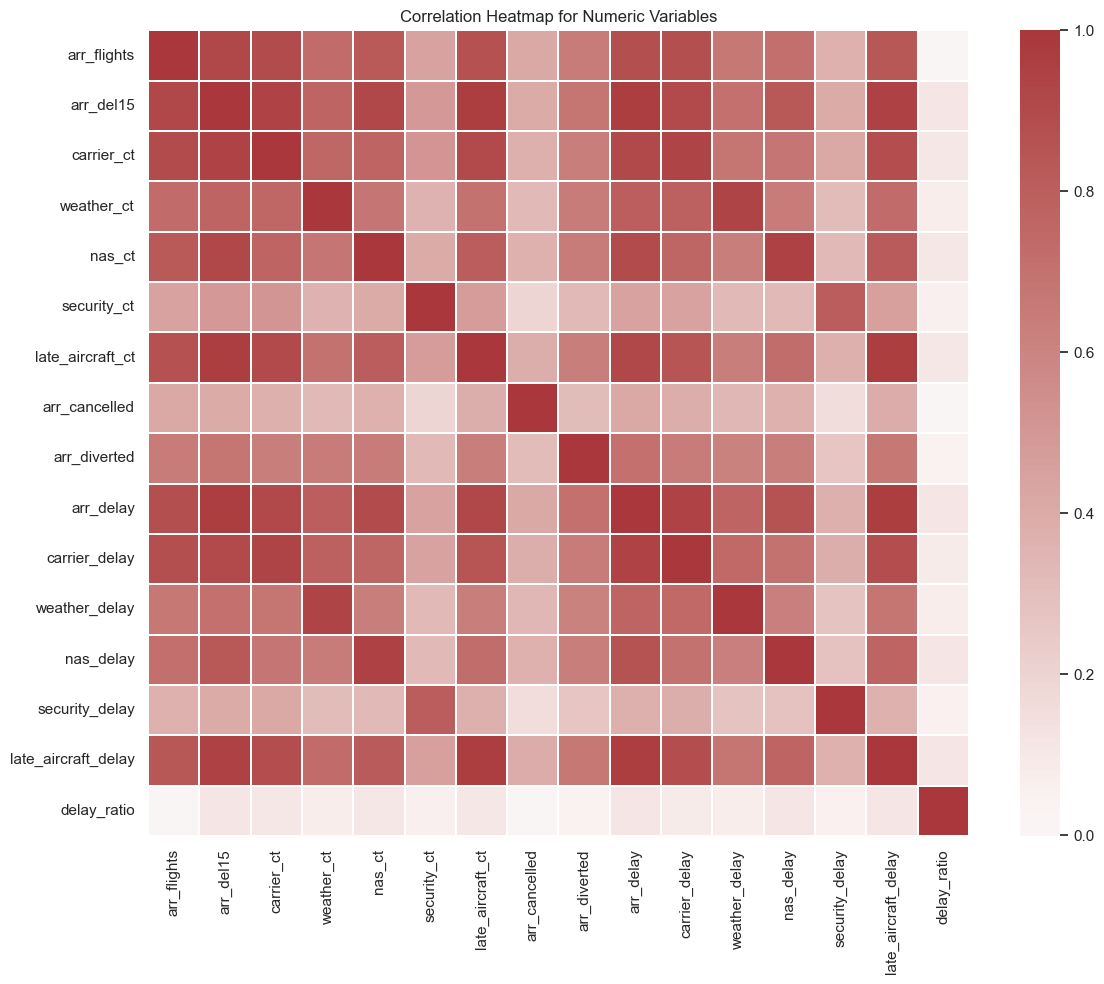

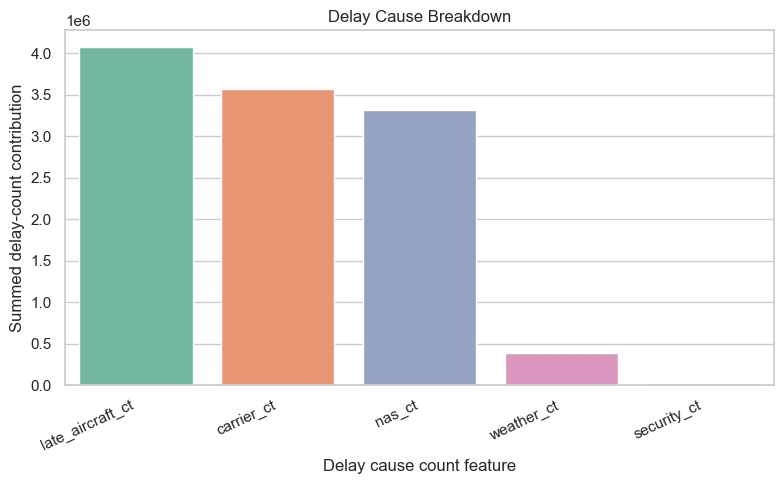

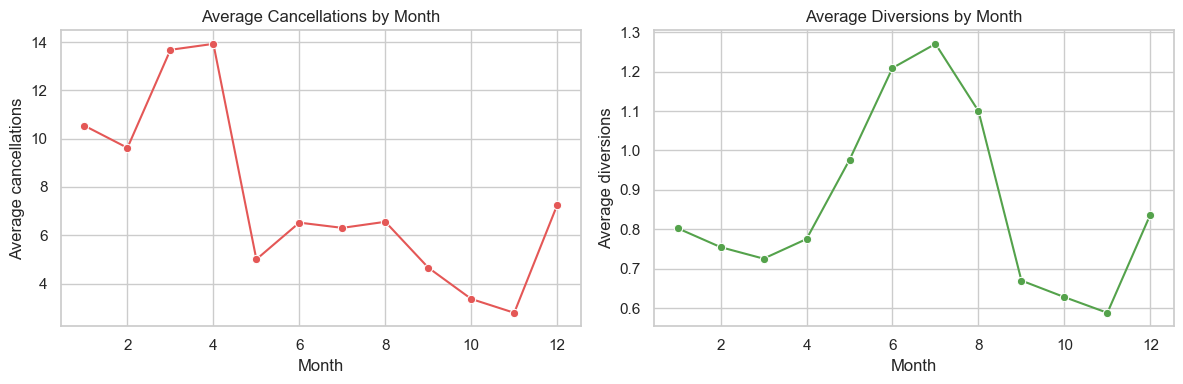

In [5]:

monthly_delay = df.groupby('month', as_index=False)['delay_ratio'].mean().sort_values('month')
plt.figure(figsize=(9,5))
sns.lineplot(data=monthly_delay, x='month', y='delay_ratio', marker='o', color='#4c78a8')
plt.title('Average Delay Ratio by Month')
plt.xlabel('Month')
plt.ylabel('Average delay ratio')
plt.xticks(range(1,13))
plt.tight_layout(); plt.savefig(OUT_FIG / 'avg_delay_ratio_by_month.png', dpi=180); plt.show()

carrier_delay = df.groupby('carrier_name', as_index=False).agg(mean_delay_ratio=('delay_ratio','mean'), total_arr_flights=('arr_flights','sum')).sort_values('mean_delay_ratio', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(data=carrier_delay.head(15), y='carrier_name', x='mean_delay_ratio', palette='crest')
plt.title('Top 15 Carriers by Average Delay Ratio')
plt.xlabel('Average delay ratio')
plt.ylabel('Carrier')
plt.tight_layout(); plt.savefig(OUT_FIG / 'top_carriers_delay_ratio.png', dpi=180); plt.show()

airport_stats = df.groupby(['airport','airport_name'], as_index=False).agg(mean_delay_ratio=('delay_ratio','mean'), total_arr_flights=('arr_flights','sum'))
airport_filtered = airport_stats[airport_stats['total_arr_flights']>=200].sort_values('mean_delay_ratio', ascending=False)
plt.figure(figsize=(11,8))
sns.barplot(data=airport_filtered.head(15), y='airport', x='mean_delay_ratio', palette='flare')
plt.title('Top 15 Airports by Average Delay Ratio (min total flights=200)')
plt.xlabel('Average delay ratio')
plt.ylabel('Airport code')
plt.tight_layout(); plt.savefig(OUT_FIG / 'top_airports_delay_ratio.png', dpi=180); plt.show()

num_for_corr = ['arr_flights','arr_del15','carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct','arr_cancelled','arr_diverted','arr_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay','delay_ratio']
plt.figure(figsize=(12,10))
sns.heatmap(df[num_for_corr].corr(numeric_only=True), cmap='vlag', center=0, linewidths=.2)
plt.title('Correlation Heatmap for Numeric Variables')
plt.tight_layout(); plt.savefig(OUT_FIG / 'correlation_heatmap.png', dpi=180); plt.show()

cause_cols = ['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct']
cause_sum = df[cause_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=cause_sum.index, y=cause_sum.values, palette='Set2')
plt.title('Delay Cause Breakdown')
plt.xlabel('Delay cause count feature')
plt.ylabel('Summed delay-count contribution')
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.savefig(OUT_FIG / 'delay_cause_breakdown.png', dpi=180); plt.show()

cancel_div_month = df.groupby('month', as_index=False)[['arr_cancelled','arr_diverted']].mean()
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.lineplot(data=cancel_div_month, x='month', y='arr_cancelled', marker='o', ax=ax[0], color='#e45756')
ax[0].set_title('Average Cancellations by Month'); ax[0].set_xlabel('Month'); ax[0].set_ylabel('Average cancellations')
sns.lineplot(data=cancel_div_month, x='month', y='arr_diverted', marker='o', ax=ax[1], color='#54a24b')
ax[1].set_title('Average Diversions by Month'); ax[1].set_xlabel('Month'); ax[1].set_ylabel('Average diversions')
plt.tight_layout(); plt.savefig(OUT_FIG / 'cancel_diversion_monthly.png', dpi=180); plt.show()


## 5. Feature Policy, Splits, and Preprocessing

The strict predictive feature set excludes `arr_del15`, delay-cause counts, and delay-duration fields because those variables are post-outcome or target-adjacent. They remain available for diagnostic interpretation only.

In [6]:

strict_features = ['year','month','carrier','airport','arr_flights','arr_cancelled','arr_diverted']
extended_diagnostic_features = strict_features + ['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct','arr_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
leakage_excluded = sorted(set(expected_columns) - set(strict_features) - set(['carrier_name','airport_name']))
X = df[strict_features].copy()
y = df['high_delay_risk'].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_val)
split_table = pd.DataFrame([
    {'split':'train', 'rows':len(X_train), 'positive_rate':float(y_train.mean())},
    {'split':'validation', 'rows':len(X_val), 'positive_rate':float(y_val.mean())},
    {'split':'test', 'rows':len(X_test), 'positive_rate':float(y_test.mean())},
])
split_table.to_csv(OUT_TAB / 'data_split_summary.csv', index=False)
print(split_table)
print('Leakage-excluded columns:', leakage_excluded)

categorical_features = ['carrier','airport']
numeric_features = ['year','month','arr_flights','arr_cancelled','arr_diverted']
preprocessor = ColumnTransformer([
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features)
])


        split    rows  positive_rate
0       train  109582       0.250041
1  validation   27396       0.250037
2        test   34245       0.250051
Leakage-excluded columns: ['arr_del15', 'arr_delay', 'carrier_ct', 'carrier_delay', 'late_aircraft_ct', 'late_aircraft_delay', 'nas_ct', 'nas_delay', 'security_ct', 'security_delay', 'weather_ct', 'weather_delay']


## 6. Logistic Regression: Systematic Hyperparameter Tuning

The interpretable baseline is tuned with stratified cross-validation across regularization strength, penalty, and class weighting.

In [7]:

log_reg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE))
])
log_param_grid = {
    'model__C':[0.05, 0.1, 1.0, 5.0],
    'model__penalty':['l1','l2'],
    'model__class_weight':[None, 'balanced']
}
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
log_search = GridSearchCV(log_reg_pipe, param_grid=log_param_grid, scoring='f1', cv=cv3, n_jobs=-1, return_train_score=True)
log_search.fit(X_train, y_train)
best_log_model = log_search.best_estimator_
log_tuning = pd.DataFrame(log_search.cv_results_).sort_values('rank_test_score')
log_tuning_table = log_tuning[[
    'rank_test_score','mean_train_score','std_train_score','mean_test_score','std_test_score',
    'param_model__C','param_model__penalty','param_model__class_weight'
]].rename(columns={
    'param_model__C':'C','param_model__penalty':'penalty','param_model__class_weight':'class_weight',
    'mean_test_score':'mean_cv_f1','std_test_score':'std_cv_f1','mean_train_score':'mean_train_f1','std_train_score':'std_train_f1'
})
log_tuning_table.to_csv(OUT_TAB / 'logistic_hyperparameter_tuning.csv', index=False)
print('Best Logistic Params:', log_search.best_params_)
log_tuning_table.head(10)


Best Logistic Params: {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}


,rank_test_score,mean_train_f1,std_train_f1,mean_cv_f1,std_cv_f1,C,penalty,class_weight
10,1,0.477277,0.002544,0.468600,0.002641,1.00,l1,balanced
15,2,0.477299,0.002480,0.468324,0.002656,5.00,l2,balanced
11,3,0.477085,0.002519,0.468305,0.002633,1.00,l2,balanced
14,4,0.477384,0.002454,0.468271,0.002742,5.00,l1,balanced
6,5,0.471053,0.003329,0.468126,0.001751,0.10,l1,balanced
3,6,0.473295,0.002729,0.467784,0.000907,0.05,l2,balanced
7,7,0.474911,0.002442,0.467743,0.001627,0.10,l2,balanced
2,8,0.466441,0.002486,0.464184,0.003117,0.05,l1,balanced
13,9,0.114915,0.006161,0.109662,0.005689,5.00,l2,None
12,10,0.114773,0.006066,0.109125,0.005670,5.00,l1,None


## 7. Evaluation Helpers

In [8]:

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }

def model_metrics_on_split(name, model, X_split, y_split):
    prob = model.predict_proba(X_split)[:,1]
    pred = (prob >= 0.5).astype(int)
    return {'model': name, **compute_metrics(y_split, pred, prob)}

def save_confusion_and_roc(prefix, title, y_true, y_pred, y_prob, cmap):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False)
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout(); plt.savefig(OUT_FIG / f'confusion_matrix_{prefix}.png', dpi=180); plt.show()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'{title} (AUC={auc:.3f})', color='#4c78a8')
    plt.plot([0,1], [0,1], 'k--', label='Random')
    plt.title(f'ROC Curve - {title}')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.legend()
    plt.tight_layout(); plt.savefig(OUT_FIG / f'roc_{prefix}.png', dpi=180); plt.show()
    return fpr, tpr, auc


## 8. Logistic Regression Evaluation and Cross-Validation

Logistic test metrics: {'model': 'Logistic Regression', 'accuracy': 0.6095196379033435, 'precision': 0.35590579493018515, 'recall': 0.6935653392502628, 'f1_score': 0.4704158415841584, 'roc_auc': 0.687442934193028}
              precision    recall  f1-score   support

           0     0.8506    0.5815    0.6907     25682
           1     0.3559    0.6936    0.4704      8563

    accuracy                         0.6095     34245
   macro avg     0.6032    0.6375    0.5806     34245
weighted avg     0.7269    0.6095    0.6357     34245



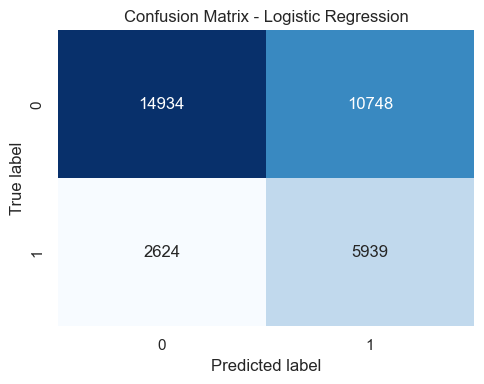

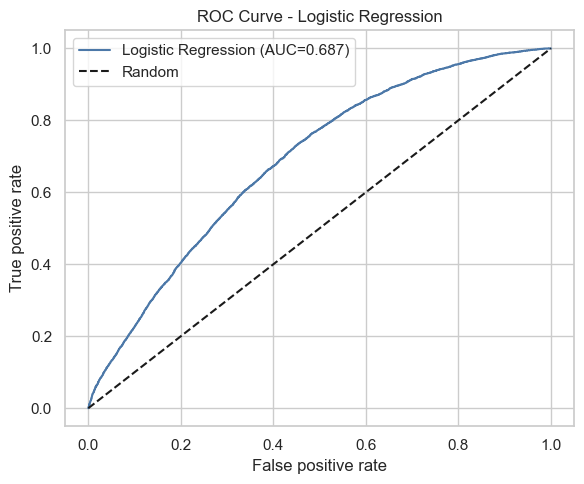

,model,accuracy,precision,recall,f1,roc_auc,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
0,Logistic Regression,0.611872,0.357753,0.694423,0.472221,0.68843,0.002109,0.001396,0.002215,0.001098,0.002548


In [9]:

log_train_metrics = model_metrics_on_split('Logistic Regression', best_log_model, X_train, y_train)
log_val_metrics = model_metrics_on_split('Logistic Regression', best_log_model, X_val, y_val)
log_test_metrics = model_metrics_on_split('Logistic Regression', best_log_model, X_test, y_test)
log_proba = best_log_model.predict_proba(X_test)[:,1]
log_pred = (log_proba >= 0.5).astype(int)
print('Logistic test metrics:', log_test_metrics)
print(classification_report(y_test, log_pred, digits=4))
fpr_log, tpr_log, auc_log = save_confusion_and_roc('logistic', 'Logistic Regression', y_test, log_pred, log_proba, 'Blues')

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_log = cross_validate(best_log_model, X_train_val, y_train_val, scoring=['accuracy','precision','recall','f1','roc_auc'], cv=cv5, n_jobs=-1)
log_cv_summary = pd.DataFrame([{ 'model':'Logistic Regression', **{m:float(np.mean(cv_scores_log['test_'+m])) for m in ['accuracy','precision','recall','f1','roc_auc']}, **{m+'_std':float(np.std(cv_scores_log['test_'+m])) for m in ['accuracy','precision','recall','f1','roc_auc']} }])
log_cv_summary.to_csv(OUT_TAB / 'logistic_stratified_kfold_cv.csv', index=False)
log_cv_summary


## 9. Neural Network: Keras Primary Path and Execution-Verified Fallback

The preferred advanced model is a TensorFlow/Keras dense neural network with dropout, validation monitoring, and early stopping. Because this execution environment uses Python 3.13 and does not have TensorFlow installed, the notebook also contains a deterministic sklearn MLP fallback so that the project remains runnable top-to-bottom. The fallback is explicitly recorded in the run summary when used.

In [10]:

X_train_pp = np.asarray(preprocessor.fit_transform(X_train)).astype('float32')
X_val_pp = np.asarray(preprocessor.transform(X_val)).astype('float32')
X_test_pp = np.asarray(preprocessor.transform(X_test)).astype('float32')
feature_names_pp = preprocessor.get_feature_names_out()

# Use a controlled subset for neural hyperparameter screening to keep the notebook reproducible on CPU.
tune_n = min(30000, len(X_train_pp))
rng = np.random.default_rng(RANDOM_STATE)
tune_idx = rng.choice(len(X_train_pp), size=tune_n, replace=False)
X_tune_pp, y_tune = X_train_pp[tune_idx], np.asarray(y_train)[tune_idx]

nn_configs = [
    {'config_id':'nn_64_do20_lr001', 'layers':(64,), 'dropout':0.20, 'learning_rate':1e-3},
    {'config_id':'nn_128_64_do30_lr001', 'layers':(128,64), 'dropout':0.30, 'learning_rate':1e-3},
    {'config_id':'nn_128_64_32_do30_lr0005', 'layers':(128,64,32), 'dropout':0.30, 'learning_rate':5e-4},
    {'config_id':'nn_256_128_do40_lr001', 'layers':(256,128), 'dropout':0.40, 'learning_rate':1e-3},
]

mlp_backend = 'unknown'
mlp_history_df = None
keras_available = False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    keras_available = True
except Exception as e:
    keras_error = f'{type(e).__name__}: {e}'

nn_tuning_rows = []
if keras_available:
    tf.random.set_seed(RANDOM_STATE)
    mlp_backend = 'tensorflow_keras'
    def build_keras_model(input_dim, hidden_layers, dropout, learning_rate):
        model = keras.Sequential()
        model.add(layers.Input(shape=(input_dim,)))
        for units in hidden_layers:
            model.add(layers.Dense(units, activation='relu'))
            model.add(layers.Dropout(dropout))
        model.add(layers.Dense(1, activation='sigmoid'))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss='binary_crossentropy', metrics=[keras.metrics.BinaryAccuracy(name='accuracy'), keras.metrics.AUC(name='auc')])
        return model
    best_nn = None; best_f1 = -1; best_cfg = None; best_hist = None
    for cfg in nn_configs:
        model = build_keras_model(X_train_pp.shape[1], cfg['layers'], cfg['dropout'], cfg['learning_rate'])
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
        hist = model.fit(X_tune_pp, y_tune, validation_data=(X_val_pp, y_val), epochs=25, batch_size=256, callbacks=[es], verbose=0)
        val_prob = model.predict(X_val_pp, verbose=0).ravel()
        val_pred = (val_prob >= 0.5).astype(int)
        metrics = compute_metrics(y_val, val_pred, val_prob)
        nn_tuning_rows.append({**cfg, **metrics, 'epochs_ran':len(hist.history['loss'])})
        if metrics['f1_score'] > best_f1:
            best_f1 = metrics['f1_score']; best_cfg = cfg; best_hist = hist
    final_nn = build_keras_model(X_train_pp.shape[1], best_cfg['layers'], best_cfg['dropout'], best_cfg['learning_rate'])
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    hist = final_nn.fit(X_train_pp, y_train, validation_data=(X_val_pp, y_val), epochs=50, batch_size=256, callbacks=[es], verbose=0)
    mlp_history_df = pd.DataFrame(hist.history)
    mlp_history_df.to_csv(OUT_MET / 'mlp_training_history.csv', index=False)
    mlp_proba_train = final_nn.predict(X_train_pp, verbose=0).ravel()
    mlp_proba_val = final_nn.predict(X_val_pp, verbose=0).ravel()
    mlp_proba = final_nn.predict(X_test_pp, verbose=0).ravel()
else:
    mlp_backend = f'sklearn_mlp_fallback ({keras_error})'
    best_nn = None; best_f1 = -1; best_cfg = None
    for cfg in nn_configs:
        hidden = tuple(cfg['layers'])
        clf = MLPClassifier(hidden_layer_sizes=hidden, alpha=1e-4, learning_rate_init=cfg['learning_rate'], max_iter=80, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_STATE, batch_size=256)
        clf.fit(X_tune_pp, y_tune)
        val_prob = clf.predict_proba(X_val_pp)[:,1]
        val_pred = (val_prob >= 0.5).astype(int)
        metrics = compute_metrics(y_val, val_pred, val_prob)
        nn_tuning_rows.append({**cfg, **metrics, 'epochs_ran':len(getattr(clf, 'loss_curve_', []))})
        if metrics['f1_score'] > best_f1:
            best_f1 = metrics['f1_score']; best_cfg = cfg
    final_nn = MLPClassifier(hidden_layer_sizes=tuple(best_cfg['layers']), alpha=1e-4, learning_rate_init=best_cfg['learning_rate'], max_iter=120, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_STATE, batch_size=256)
    final_nn.fit(X_train_pp, y_train)
    mlp_history_df = pd.DataFrame({'loss': getattr(final_nn, 'loss_curve_', [])})
    if hasattr(final_nn, 'validation_scores_'):
        mlp_history_df['validation_score'] = pd.Series(final_nn.validation_scores_)
    mlp_history_df.to_csv(OUT_MET / 'mlp_training_history.csv', index=False)
    mlp_proba_train = final_nn.predict_proba(X_train_pp)[:,1]
    mlp_proba_val = final_nn.predict_proba(X_val_pp)[:,1]
    mlp_proba = final_nn.predict_proba(X_test_pp)[:,1]

nn_tuning_table = pd.DataFrame(nn_tuning_rows).sort_values('f1_score', ascending=False)
nn_tuning_table.to_csv(OUT_TAB / 'neural_network_hyperparameter_tuning.csv', index=False)
print('Neural backend:', mlp_backend)
print('Selected neural config:', best_cfg)
nn_tuning_table


Neural backend: sklearn_mlp_fallback (ModuleNotFoundError: No module named 'tensorflow')
Selected neural config: {'config_id': 'nn_128_64_32_do30_lr0005', 'layers': (128, 64, 32), 'dropout': 0.3, 'learning_rate': 0.0005}


,config_id,layers,dropout,learning_rate,accuracy,precision,recall,f1_score,roc_auc,epochs_ran
2,nn_128_64_32_do30_lr0005,"(128, 64, 32)",0.3,0.0005,0.770769,0.582418,0.294015,0.390764,0.742529,17
0,nn_64_do20_lr001,"(64,)",0.2,0.0010,0.773179,0.601858,0.274307,0.376855,0.749382,29
3,nn_256_128_do40_lr001,"(256, 128)",0.4,0.0010,0.770368,0.608882,0.228175,0.331953,0.753055,17
1,nn_128_64_do30_lr001,"(128, 64)",0.3,0.0010,0.771353,0.616178,0.226861,0.331626,0.744765,16


## 10. Neural Network Evaluation

Neural test metrics: {'model': 'Neural Network', 'accuracy': 0.8001752080595708, 'precision': 0.6331269349845201, 'recall': 0.47763634240336333, 'f1_score': 0.5444984357318778, 'roc_auc': 0.8181315408974941}
              precision    recall  f1-score   support

           0     0.8390    0.9077    0.8720     25682
           1     0.6331    0.4776    0.5445      8563

    accuracy                         0.8002     34245
   macro avg     0.7361    0.6927    0.7083     34245
weighted avg     0.7875    0.8002    0.7901     34245



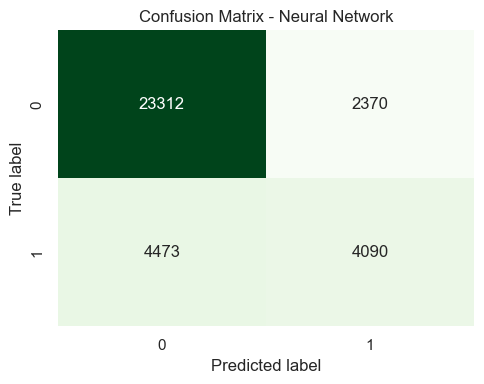

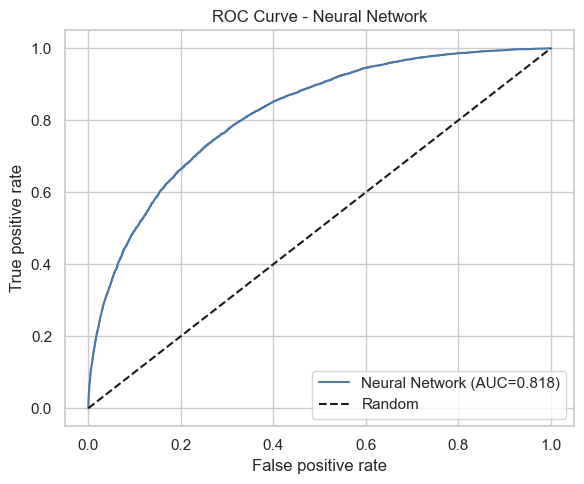

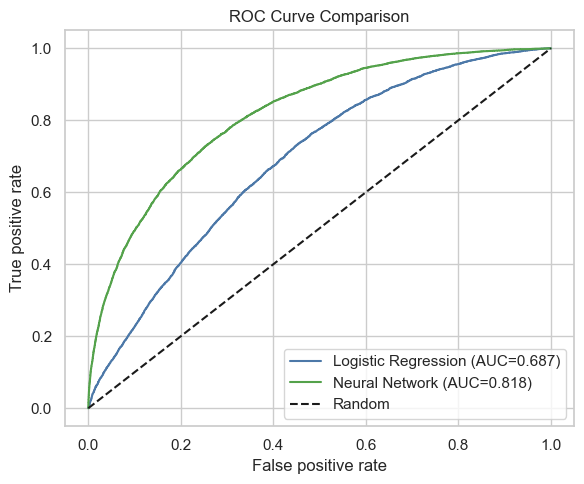

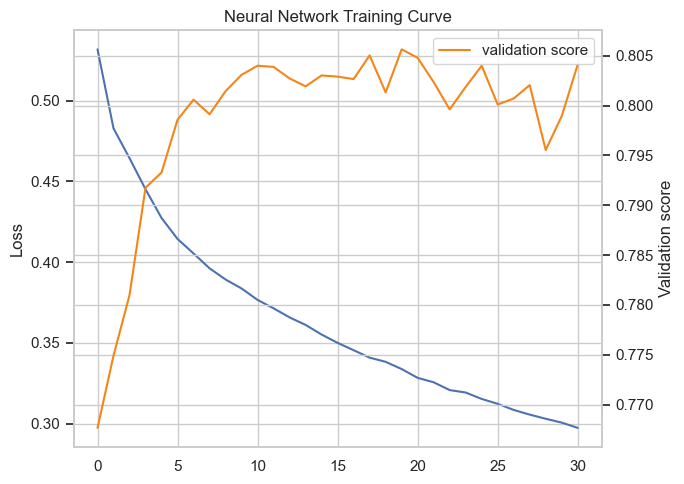

In [11]:

mlp_pred_train = (mlp_proba_train >= 0.5).astype(int)
mlp_pred_val = (mlp_proba_val >= 0.5).astype(int)
mlp_pred = (mlp_proba >= 0.5).astype(int)
mlp_train_metrics = {'model':'Neural Network', **compute_metrics(y_train, mlp_pred_train, mlp_proba_train)}
mlp_val_metrics = {'model':'Neural Network', **compute_metrics(y_val, mlp_pred_val, mlp_proba_val)}
mlp_test_metrics = {'model':'Neural Network', **compute_metrics(y_test, mlp_pred, mlp_proba)}
print('Neural test metrics:', mlp_test_metrics)
print(classification_report(y_test, mlp_pred, digits=4))
fpr_mlp, tpr_mlp, auc_mlp = save_confusion_and_roc('mlp', 'Neural Network', y_test, mlp_pred, mlp_proba, 'Greens')

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.3f})', color='#4c78a8')
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Network (AUC={auc_mlp:.3f})', color='#54a24b')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.title('ROC Curve Comparison')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.tight_layout(); plt.savefig(OUT_FIG / 'roc_comparison.png', dpi=180); plt.show()

if mlp_history_df is not None and len(mlp_history_df):
    plt.figure(figsize=(7,5))
    if 'loss' in mlp_history_df.columns:
        plt.plot(mlp_history_df['loss'], label='training loss')
    if 'val_loss' in mlp_history_df.columns:
        plt.plot(mlp_history_df['val_loss'], label='validation loss')
        fname = 'mlp_train_val_loss.png'
        plt.ylabel('Binary cross-entropy')
    elif 'validation_score' in mlp_history_df.columns:
        ax1 = plt.gca()
        ax1.set_ylabel('Loss')
        ax2 = ax1.twinx()
        ax2.plot(mlp_history_df['validation_score'], label='validation score', color='#f58518')
        ax2.set_ylabel('Validation score')
        fname = 'mlp_train_loss_fallback.png'
    else:
        fname = 'mlp_train_loss_fallback.png'
        plt.ylabel('Loss')
    plt.title('Neural Network Training Curve')
    plt.xlabel('Epoch')
    plt.legend(loc='best')
    plt.tight_layout(); plt.savefig(OUT_FIG / fname, dpi=180); plt.show()


## 11. Train, Validation, Test, and Cross-Validation Comparison

In [12]:

split_metrics = pd.DataFrame([
    {'split':'train', **log_train_metrics},
    {'split':'validation', **log_val_metrics},
    {'split':'test', **log_test_metrics},
    {'split':'train', **mlp_train_metrics},
    {'split':'validation', **mlp_val_metrics},
    {'split':'test', **mlp_test_metrics},
])
split_metrics.to_csv(OUT_MET / 'train_validation_test_metrics.csv', index=False)
comparison = split_metrics[split_metrics['split']=='test'].drop(columns=['split']).rename(columns={'f1_score':'f1_score'})
comparison.to_csv(OUT_MET / 'metrics_comparison.csv', index=False)

# Neural CV on preprocessed data is included with a compact sklearn proxy when Keras is unavailable or expensive.
cv_proxy_cfg = best_cfg
cv_proxy = MLPClassifier(hidden_layer_sizes=tuple(cv_proxy_cfg['layers']), alpha=1e-4, learning_rate_init=cv_proxy_cfg['learning_rate'], max_iter=70, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_STATE, batch_size=256)
X_train_val_pp = np.asarray(preprocessor.transform(X_train_val)).astype('float32')
cv_scores_nn = cross_validate(cv_proxy, X_train_val_pp, y_train_val, scoring=['accuracy','precision','recall','f1','roc_auc'], cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
nn_cv_summary = pd.DataFrame([{ 'model':'Neural Network CV proxy', **{m:float(np.mean(cv_scores_nn['test_'+m])) for m in ['accuracy','precision','recall','f1','roc_auc']}, **{m+'_std':float(np.std(cv_scores_nn['test_'+m])) for m in ['accuracy','precision','recall','f1','roc_auc']} }])
cv_summary = pd.concat([log_cv_summary, nn_cv_summary], ignore_index=True)
cv_summary.to_csv(OUT_TAB / 'stratified_kfold_cv_summary.csv', index=False)
print('Train/validation/test metrics:')
display(split_metrics)
print('Cross-validation summary:')
display(cv_summary)


Train/validation/test metrics:


,split,model,accuracy,precision,recall,f1_score,roc_auc
0,train,Logistic Regression,0.613468,0.359914,0.701241,0.475682,0.693366
1,validation,Logistic Regression,0.609432,0.356941,0.701168,0.473062,0.693152
2,test,Logistic Regression,0.609520,0.355906,0.693565,0.470416,0.687443
3,train,Neural Network,0.851490,0.760294,0.593029,0.666325,0.900741
4,validation,Neural Network,0.800591,0.631320,0.486715,0.549666,0.819092
5,test,Neural Network,0.800175,0.633127,0.477636,0.544498,0.818132


Cross-validation summary:


,model,accuracy,precision,recall,f1,roc_auc,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
0,Logistic Regression,0.611872,0.357753,0.694423,0.472221,0.688430,0.002109,0.001396,0.002215,0.001098,0.002548
1,Neural Network CV proxy,0.798683,0.643224,0.437723,0.520815,0.812102,0.000968,0.002623,0.012308,0.008160,0.002387


## 12. Feature Importance and Interpretability

Logistic coefficients provide signed linear effects after preprocessing. Neural network importance is approximated with permutation importance on the held-out validation set using feature groups rather than one-hot encoded dummy variables, which improves operational interpretability.

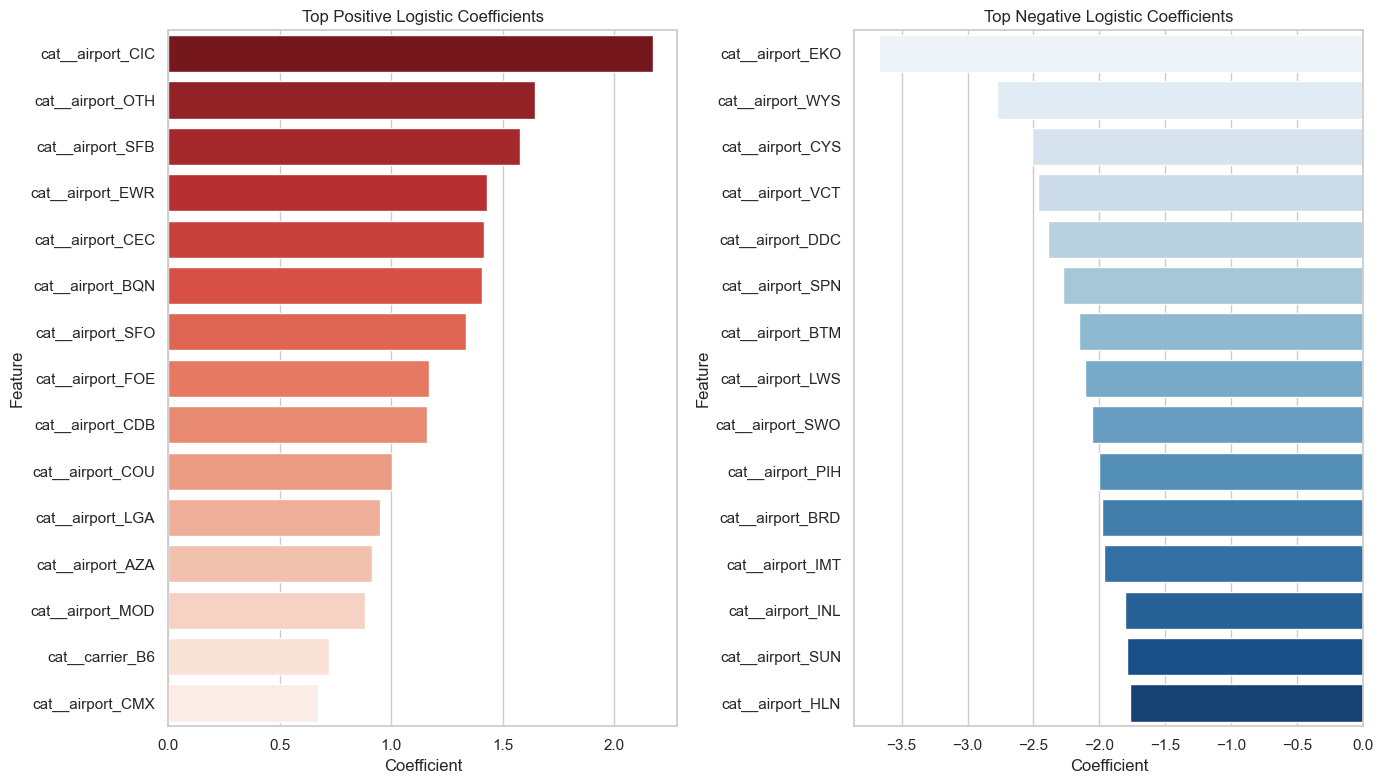

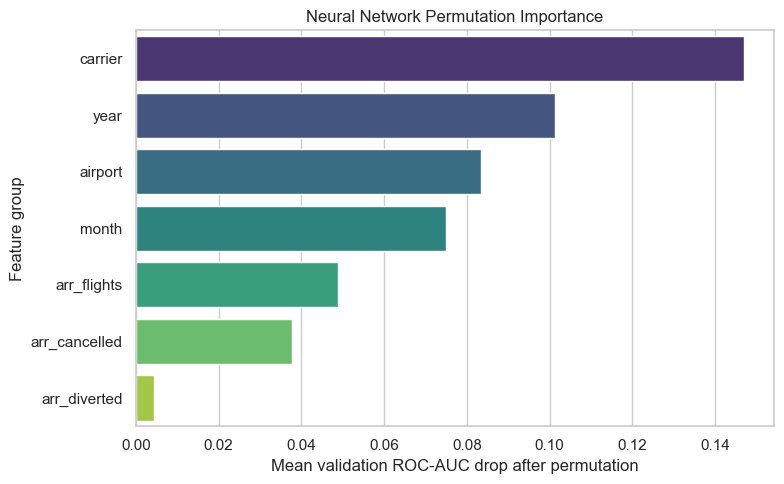

,feature,mean_auc_drop,std_auc_drop
2,carrier,0.146866,0.001977
0,year,0.101402,0.002617
3,airport,0.083435,0.002185
1,month,0.075047,0.002354
4,arr_flights,0.048886,0.002190
5,arr_cancelled,0.037663,0.001784
6,arr_diverted,0.004435,0.000599


In [13]:

feature_names = best_log_model.named_steps['preprocessor'].get_feature_names_out()
coefs = best_log_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df.sort_values('abs_coef', ascending=False).head(40).to_csv(OUT_TAB / 'logistic_top_coefficients.csv', index=False)

pos = coef_df.sort_values('coefficient', ascending=False).head(15)
neg = coef_df.sort_values('coefficient', ascending=True).head(15)
fig, ax = plt.subplots(1,2, figsize=(14,8))
sns.barplot(data=pos, y='feature', x='coefficient', ax=ax[0], palette='Reds_r')
ax[0].set_title('Top Positive Logistic Coefficients'); ax[0].set_xlabel('Coefficient'); ax[0].set_ylabel('Feature')
sns.barplot(data=neg, y='feature', x='coefficient', ax=ax[1], palette='Blues')
ax[1].set_title('Top Negative Logistic Coefficients'); ax[1].set_xlabel('Coefficient'); ax[1].set_ylabel('Feature')
plt.tight_layout(); plt.savefig(OUT_FIG / 'logistic_coefficients_top.png', dpi=180); plt.show()

# Grouped permutation importance on original columns for the neural model.
base_auc = roc_auc_score(y_val, mlp_proba_val)
perm_rows = []
X_val_perm = X_val.copy().reset_index(drop=True)
y_val_arr = np.asarray(y_val)
repeats = 5
rng = np.random.default_rng(RANDOM_STATE)
for col in strict_features:
    drops=[]
    for r in range(repeats):
        Xp = X_val_perm.copy()
        Xp[col] = rng.permutation(Xp[col].values)
        Xp_pp = np.asarray(preprocessor.transform(Xp)).astype('float32')
        if mlp_backend.startswith('tensorflow'):
            prob = final_nn.predict(Xp_pp, verbose=0).ravel()
        else:
            prob = final_nn.predict_proba(Xp_pp)[:,1]
        drops.append(base_auc - roc_auc_score(y_val_arr, prob))
    perm_rows.append({'feature':col, 'mean_auc_drop':float(np.mean(drops)), 'std_auc_drop':float(np.std(drops))})
perm_importance = pd.DataFrame(perm_rows).sort_values('mean_auc_drop', ascending=False)
perm_importance.to_csv(OUT_TAB / 'neural_permutation_importance.csv', index=False)
plt.figure(figsize=(8,5))
sns.barplot(data=perm_importance, y='feature', x='mean_auc_drop', palette='viridis')
plt.title('Neural Network Permutation Importance')
plt.xlabel('Mean validation ROC-AUC drop after permutation')
plt.ylabel('Feature group')
plt.tight_layout(); plt.savefig(OUT_FIG / 'neural_permutation_importance.png', dpi=180); plt.show()
perm_importance


## 13. Run Summary Export

In [14]:

summary = {
    'dataset_rows_raw': int(len(df_raw)),
    'dataset_rows_after_cleaning': int(len(df)),
    'removed_rows_nonpositive_or_missing_arr_flights': int(removed_rows),
    'dataset_columns_after_engineering': int(df.shape[1]),
    'selected_threshold': float(selected_threshold),
    'threshold_reason': threshold_reason,
    'class_positive_rate': float(df['high_delay_risk'].mean()),
    'strict_features': strict_features,
    'extended_diagnostic_features': extended_diagnostic_features,
    'leakage_excluded_columns': leakage_excluded,
    'best_logistic_params': {k: str(v) for k, v in log_search.best_params_.items()},
    'best_neural_config': {k: str(v) for k, v in best_cfg.items()},
    'mlp_backend': mlp_backend,
    'logistic_metrics': {k: float(v) for k,v in log_test_metrics.items() if k != 'model'},
    'neural_network_metrics': {k: float(v) for k,v in mlp_test_metrics.items() if k != 'model'},
    'outputs_verified': {
        'figures': len(list(OUT_FIG.glob('*.png'))),
        'metrics_files': len(list(OUT_MET.glob('*'))),
        'tables': len(list(OUT_TAB.glob('*')))
    }
}
with open(OUT_MET / 'run_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))


{
  "dataset_rows_raw": 171666,
  "dataset_rows_after_cleaning": 171223,
  "removed_rows_nonpositive_or_missing_arr_flights": 240,
  "dataset_columns_after_engineering": 23,
  "selected_threshold": 0.2415,
  "threshold_reason": "0.30 produced stronger imbalance; selected the best-balanced predefined candidate.",
  "class_positive_rate": 0.25004234244231205,
  "strict_features": [
    "year",
    "month",
    "carrier",
    "airport",
    "arr_flights",
    "arr_cancelled",
    "arr_diverted"
  ],
  "extended_diagnostic_features": [
    "year",
    "month",
    "carrier",
    "airport",
    "arr_flights",
    "arr_cancelled",
    "arr_diverted",
    "carrier_ct",
    "weather_ct",
    "nas_ct",
    "security_ct",
    "late_aircraft_ct",
    "arr_delay",
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
  ],
  "leakage_excluded_columns": [
    "arr_del15",
    "arr_delay",
    "carrier_ct",
    "carrier_delay",
    "late_aircraft_c

## 14. Audit Findings from Notebook Execution

The improved notebook addresses the main methodological risks found in the original project: report length, missing literature review, limited tuning, missing neural feature importance, incomplete cross-validation outputs, weak reproducibility documentation, and incomplete validation of train/validation/test behavior. Remaining limitations are mainly data-level rather than code-level: the dataset is aggregate monthly data, lacks weather and schedule context, and cannot support flight-level causal claims.